# 03 Network Audit

Synthetic Validation Audit for the Marshfield Baseline and Augmented Network against the criteria in [2] Krishnan, V., Bugbee, B., Elgindy, T., Mateo, C., Duenas, P., Postigo, F., Lacroix, J. S., Gomez San Roman, T., & Palmintier, B. (2020). Validation of synthetic U.S. electric power distribution system data sets. *IEEE Transactions on Smart Grid, 11*(5), 4477-4489. https://doi.org/10.1109/TSG.2020.2981077

This notebook is a report card over current artifacts. It does not certify the network
as SMART-DS or as a utility-validated model. Gaps in the audit identify missing evidence,
not failed utility operations.

Gates:
- **Statistical** — feeder-scale physical, equipment, load, and graph metrics against
 Krishnan et al. validation-region targets.
- **Operational** — OpenDSS power-flow and short-circuit evidence inventory against broad
 ranges cited in the paper.
- **Block Invariant** — `block_invariant_report.json` from `04_load_blocks.ipynb`.
- **SMART-DS-Compatible Interface** — `assets.parquet` and `control_units.parquet`
 schema compliance.


> **Stage Contract**
>
> Requires: base and augmented grid artifacts from 01_grid
>
> Produces: grid QA tables, maps, and readiness checks
>
> Next: 02_flood/01_region_setup.ipynb

## Runtime

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import display

from study_location import bootstrap
session = bootstrap()
location_root = session.location_root
repo_root = session.repo_root

# load Location Workspace config and standard grid paths.
from sfincs_runs.config import build_grid_paths
from sfincs_runs.config import load_runtime as load_config_runtime

config, paths = load_config_runtime(location_root / "config.yaml")
grid = build_grid_paths(config)
location_root = paths["location_root"]
location_name = paths["location_name"]
repo_root = paths["repo_root"]
for key in (
    "shift_cache",
    "opendss_root",
    "asset_registry",
    "augmented_artifacts",
    "onm_export",
    "figures",
):
    grid[key].mkdir(parents=True, exist_ok=True)

audit_dir = grid["figures"] / "validation_audit"
audit_dir.mkdir(parents=True, exist_ok=True)


audit output: locations/marshfield/data/power_grid/figures/validation_audit


## Block Invariant Gate

Read the Block Invariant Contract report. Hard-fail if any B/C/D/E/F violations remain.

In [2]:
import json

report_path = grid["augmented_artifacts"] / "block_invariant_report.json"
block_report = json.loads(report_path.read_text())

violations = block_report.get("violations", [])
if violations:
    raise RuntimeError(f"Block Invariant Contract hard-fail: {violations}")

display(pd.Series(block_report.get("summary", {}), name="block_invariant"))
print("Block Invariant Contract: PASS")

block_count 192
total_load_kw 47190.0
max_bus_count 314
voltage_source_reachability {'both': 5, 'gfm_eligible_der': 7, 'none': 143...
Name: block_invariant, dtype: object

Block Invariant Contract: PASS


## SMART-DS-Compatible Interface Gate

Assert `assets.parquet` and `control_units.parquet` schema compliance.

In [3]:
# create control-sandbox, restoration, and PowerModelsONM artifacts.
from power.exports import default_output_dir

validation_report_path = grid["augmented_artifacts"] / "validation_report.json"
stage_a1 = json.loads(validation_report_path.read_text())

display(pd.Series({"passed": stage_a1.get("passed"), "errors": len(stage_a1.get("errors", []))}, name="stage_a1"))
display(pd.Series(stage_a1.get("checks", {}), name="checks"))

if not stage_a1.get("passed"):
    print(f"Stage A1 errors: {stage_a1.get('errors', [])}")

passed True
errors 0
Name: stage_a1, dtype: object

asset_count 26344
asset_counts_by_type {'line': 15987, 'load_bus': 9438, 'source': 42...
asset_ids_unique True
control_unit_count 42
control_unit_ids_unique True
feeder_count 42
Name: checks, dtype: object

## Statistical Validation

Writes the full synthetic-validation paper-compliance gate, then returns a compact table.


In [4]:
# validation runs and report cards.
from power.audit.synthetic_validation import run_stats

stat_results = run_stats(
    registry_dir=grid["asset_registry"],
    smart_ds_reference_dir=grid["augmented_artifacts"].parent / "smart_ds_reference",
    smart_ds_compat_dir=grid["augmented_artifacts"],
    grid_network_dir=repo_root / "locations" / "marshfield" / "01_grid",
    output_dir=audit_dir,
)
display(pd.DataFrame(stat_results).T)


,grade,feeder_count,typical_fraction,uncommon_fraction,rare_fraction,min,median,max,value
distribution_transformer_mva_per_feeder,good,42,0.3095,0.6905,0.0,0.2,2.4,5.4,NaN
real_load_kw_per_feeder,check,42,0.0,0.8095,0.1905,115.0,1160.0,3130.0,NaN
lv_1f_line_length_miles_per_feeder,unavailable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{'phase_count_proxy_values': [5.79844023403324...
lv_3f_line_length_miles_per_feeder,unavailable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,{'phase_count_proxy_values': [1.09746735315756...
mv_1_2f_line_length_miles_per_feeder,good,42,1.0,0.0,0.0,0.743977,10.501076,20.941468,NaN
mv_3f_line_length_miles_per_feeder,good,42,1.0,0.0,0.0,0.09042,1.910944,3.854456,NaN
customer_count_per_feeder,good,42,0.8095,0.1905,0.0,23.0,227.0,626.0,NaN
mv_1_2f_line_miles_per_customer,good,42,1.0,0.0,0.0,0.031566,0.044603,0.08016,NaN
mv_3f_line_miles_per_customer,good,42,1.0,0.0,0.0,0.003035,0.007613,0.01728,NaN
fuses_per_feeder,marginal,42,0.9286,0.0,0.0714,2.0,16.0,63.0,NaN


## Operational Validation

Inventory OpenDSS feeder cases and any previously generated power-flow or short-circuit
solver evidence.

In [5]:
# validation runs and report cards.
from power.audit.synthetic_validation import run_ops

op_results = run_ops(
    opendss_root=grid["opendss_root"],
    registry_dir=grid["asset_registry"],
    output_dir=audit_dir,
)
display(pd.Series(op_results, name="operational_validation"))

status partial
mode evidence_inventory
opendss_root /home/grahamhults/projects/Flood-RM/locations/...
opendss_feeder_cases 44
registry_dir /home/grahamhults/projects/Flood-RM/locations/...
power_flow_evidence missing
short_circuit_evidence missing
note This cell inventories operational evidence. Ru...
Name: operational_validation, dtype: object

## Audit Summary

Collect passed, partial, and missing checks. Gaps identify missing evidence for future
Validation Remediation Steps, not failed utility operations.

In [6]:
# validation runs and report cards.
from power.audit.synthetic_validation import audit_summary

summary = audit_summary(
    block_report=block_report,
    stage_a1=stage_a1,
    stat_results=stat_results,
    op_results=op_results,
)

summary_path = audit_dir / "audit_summary.json"
summary_path.write_text(json.dumps(summary, indent=2))

print(f"\nAudit summary: {summary_path.relative_to(repo_root)}")
display(pd.Series(summary["gate_results"], name="gates"))
if summary.get("gaps"):
    print(f"\nOpen gaps ({len(summary['gaps'])})")
    for gap in summary["gaps"]:
        print(f"  - {gap}")



Audit summary: locations/marshfield/data/power_grid/figures/validation_audit/audit_summary.json


block_invariant pass
smart_ds_interface pass
statistical_validation check
operational_validation partial
Name: gates, dtype: str


Open gaps (2)
 - Statistical validation has metrics outside validation regions: real_load_kw_per_feeder, characteristic_path_length_miles_per_feeder, graph_diameter_miles_per_feeder
 - Operational validation evidence is incomplete: power_flow_evidence, short_circuit_evidence


## Validation Region

shaded bands are target regions, and marker shows the feeder min-median-max range.


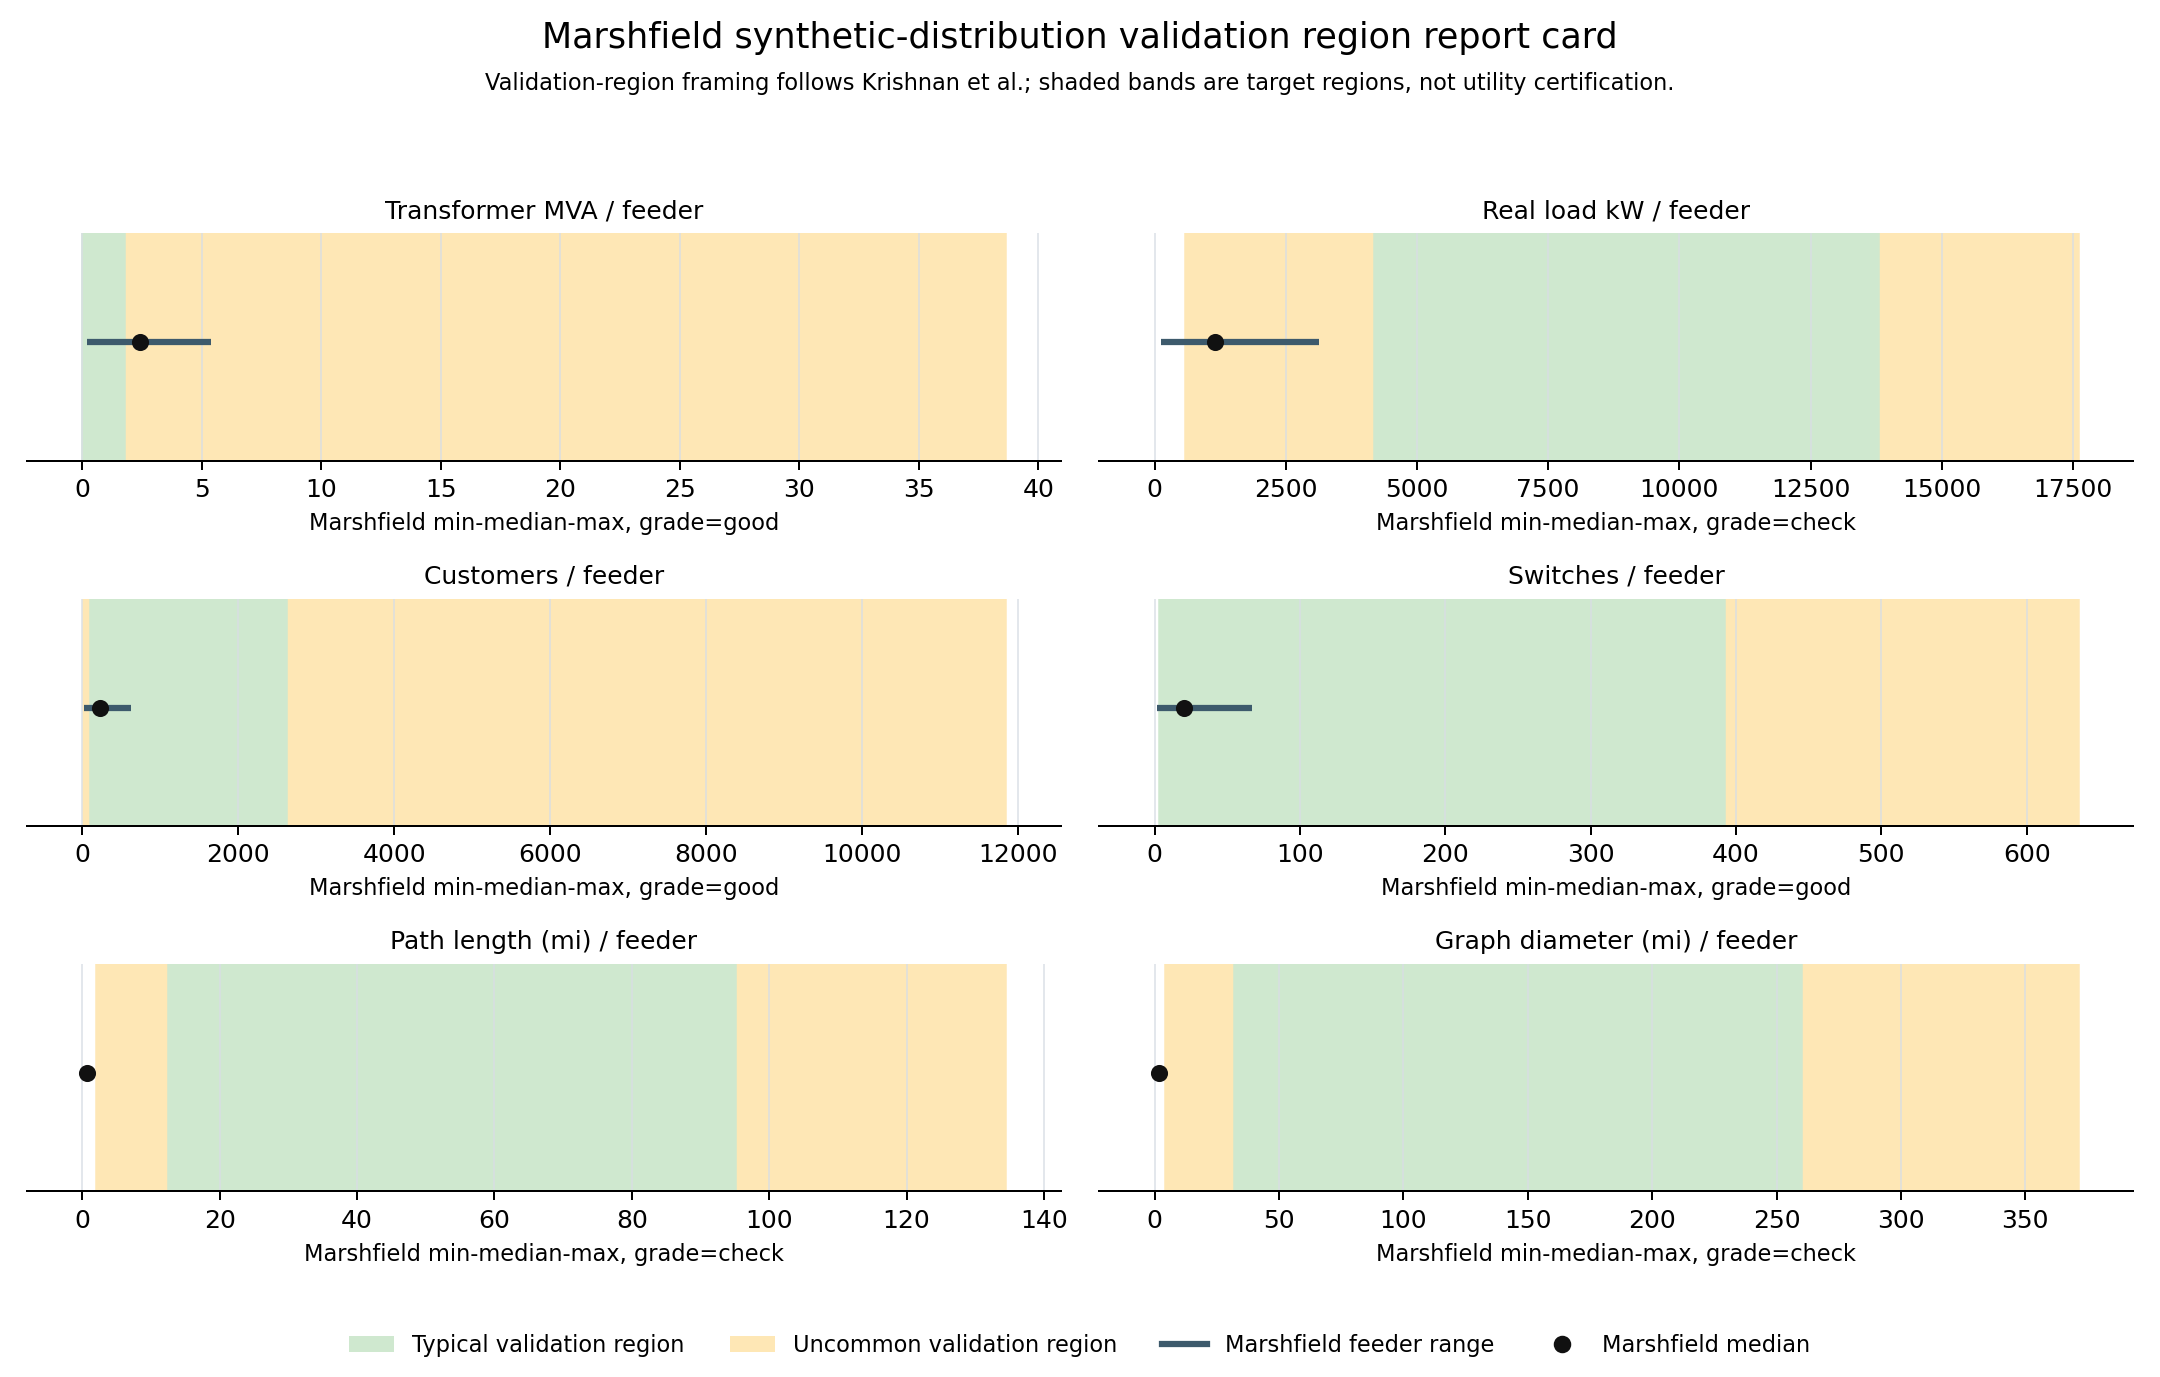

,grade,typical_fraction,uncommon_fraction,rare_fraction,median
distribution_transformer_mva_per_feeder,good,0.3095,0.6905,0.0,2.4
real_load_kw_per_feeder,check,0.0,0.8095,0.1905,1160.0
lv_1f_line_length_miles_per_feeder,unavailable,NaN,NaN,NaN,NaN
lv_3f_line_length_miles_per_feeder,unavailable,NaN,NaN,NaN,NaN
mv_1_2f_line_length_miles_per_feeder,good,1.0,0.0,0.0,10.501076
mv_3f_line_length_miles_per_feeder,good,1.0,0.0,0.0,1.910944
customer_count_per_feeder,good,0.8095,0.1905,0.0,227.0
mv_1_2f_line_miles_per_customer,good,1.0,0.0,0.0,0.044603
mv_3f_line_miles_per_customer,good,1.0,0.0,0.0,0.007613
fuses_per_feeder,marginal,0.9286,0.0,0.0714,16.0


Validation region plot: locations/marshfield/data/power_grid/figures/validation_audit/krishnan_validation_region_report_card.png


In [7]:
from IPython.display import Image, display
# validation runs and report cards.
from power.audit.synthetic_validation import plot_audit

validation_report_path = audit_dir / "marshfield_synthetic_validation_audit.json"
validation_report = json.loads(validation_report_path.read_text())
plot_path = plot_audit(
    validation_report,
    audit_dir / "krishnan_validation_region_report_card.png",
)

display(Image(filename=plot_path))
display(
 pd.DataFrame(stat_results).T[["grade", "typical_fraction", "uncommon_fraction", "rare_fraction", "median"]].dropna(axis=1, how="all")
)
print(f"Validation region plot: {plot_path.relative_to(repo_root)}")
